# This Notebook is used to create a visual representation of the Localization offset 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import PIL
import json
from PIL import Image
import os

In [ ]:
poses=[]
vertex_ids = []
vertex_times = []
times = []
folder_path = '/home/adam/Desktop/CurrentBranch/src/main/src/vtr_db_extractor/loc_results'
file_count = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
print(f"Number of files: {file_count}")
for i in range(0,file_count,1):
    filename = filename=folder_path+f"/T_r_vertex_{i:04d}.txt"
    matrix = []
    
    with open(filename, 'r') as file:
        for line in file:
            # Skip empty lines
            if line.startswith('vertex_id:'):
                vertex_id =int(line.split(": ")[1].strip())
                vertex_ids.append(vertex_id)
            elif line.startswith('vertex_timestamp:'):
                vertex_time =int(line.split(": ")[1].strip())
                vertex_times.append(vertex_time)
            elif line.startswith("timestamp:"):
                time =int(line.split(": ")[1].strip())
                times.append(time)
            elif line.strip() and not line.startswith('u'):
                # Split the line by whitespace and convert each element to float
                row = [float(val) for val in line.strip().split()]
                matrix.append(row)
            

    temp = np.array(matrix[0:4])
    poses.append(np.array(matrix[0:4]))
poses=np.array(poses)
times= np.array(times)
vertex_ids = np.array(vertex_ids)
vertex_times= np.array(vertex_times)

Number of files: 8022


In [ ]:
print(vertex_ids[4588:4600])
print(vertex_ids[4586])
print(vertex_ids[4587])

pose1 = poses[0:4587].copy()
pose2 = poses[4588:].copy()
vertex_ids1 = vertex_ids[0:4587].copy()
vertex_ids2 = vertex_ids[4588:].copy()

[0 0 0 0 0 0 0 0 0 0 0 0]
883
0


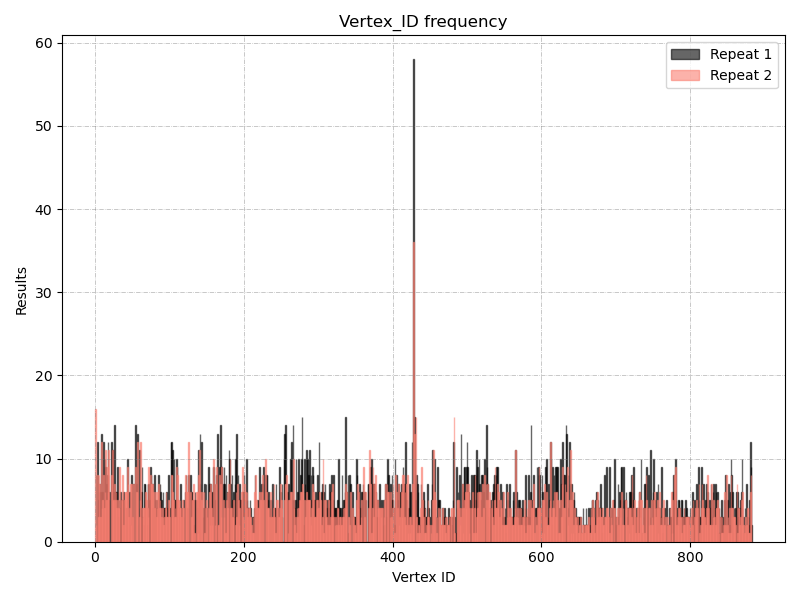

In [30]:
%matplotlib ipympl
fig, axs = plt.subplots(1, 1, figsize =(8, 6), tight_layout = True)
axs.grid( color ='grey', linestyle ='-.', linewidth = 0.5, alpha = 0.6) 
plt.hist(vertex_ids1, bins=max(vertex_ids1), color='black', edgecolor='black', alpha=0.6, label='Repeat 1') # color='skyblue'
plt.hist(vertex_ids2, bins=max(vertex_ids2), color='salmon', edgecolor='salmon', alpha=0.6, label='Repeat 2')
plt.xlabel('Vertex ID')
plt.ylabel('Results')
plt.legend()
plt.title('Vertex_ID frequency')
plt.show()

/tmp/ipykernel_9921/353120491.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(origins2[:,1], 'k--', linewidth=0.5, color='salmon')


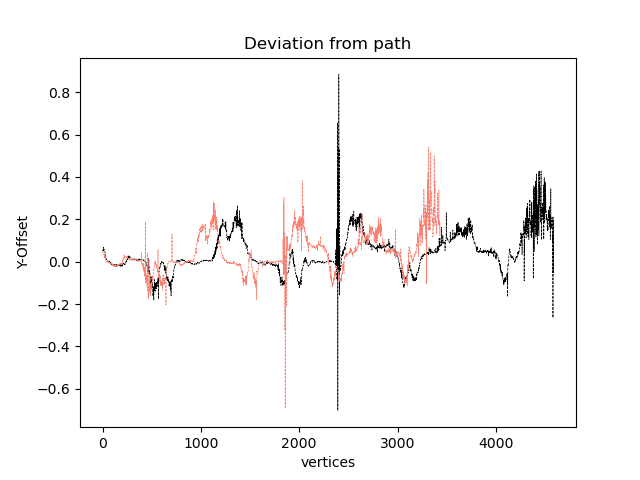

In [33]:

%matplotlib ipympl
# Graph of the y distance to vertex.
origins1 = pose1[:, :3, -1]
origins2 = pose2[:, :3, -1]
plt.plot(origins1[:,1], 'k--', linewidth=0.5)
plt.plot(origins2[:,1], 'k--', linewidth=0.5, color='salmon')
plt.xlabel("vertices")
plt.ylabel("Y-Offset")
plt.title("Deviation from path")
plt.show()

[[-9.04046e-02  5.30407e-02  6.04995e-03]
 [-9.22704e-02  5.33242e-02  6.76036e-03]
 [-9.06316e-02  5.29876e-02  6.10847e-03]
 [-9.04464e-02  5.31583e-02  6.09230e-03]
 [-8.31921e-02  5.64873e-02  3.82476e-03]
 [-9.13912e-02  5.32719e-02  6.38476e-03]
 [-9.11145e-02  5.30178e-02  6.35768e-03]
 [-1.11148e-01  5.16517e-02  3.12660e-03]
 [ 2.18137e-01  5.49486e-02 -2.00792e-02]
 [ 2.12156e-01  6.84573e-02 -5.95921e-03]
 [ 5.96648e-03  5.66646e-02  5.25265e-03]
 [ 6.01709e-03  5.68658e-02  5.69262e-03]
 [ 6.88551e-03  5.59907e-02  4.87967e-03]
 [-7.12563e-02  5.58466e-02  7.00413e-03]
 [-7.16988e-02  5.58370e-02  7.06445e-03]
 [-7.19220e-02  5.60044e-02  7.50965e-03]
 [-7.11372e-02  5.59843e-02  7.10313e-03]
 [-7.11110e-02  5.59815e-02  7.09890e-03]
 [-7.10670e-02  5.59832e-02  7.12389e-03]
 [-2.47855e-01  5.71947e-02  1.48183e-02]
 [-2.94059e-02  5.02769e-02 -5.75724e-04]
 [-2.94075e-02  5.02090e-02 -5.88734e-04]
 [-2.93280e-02  5.01577e-02 -5.70552e-04]
 [-2.94496e-02  5.01810e-02 -6.339

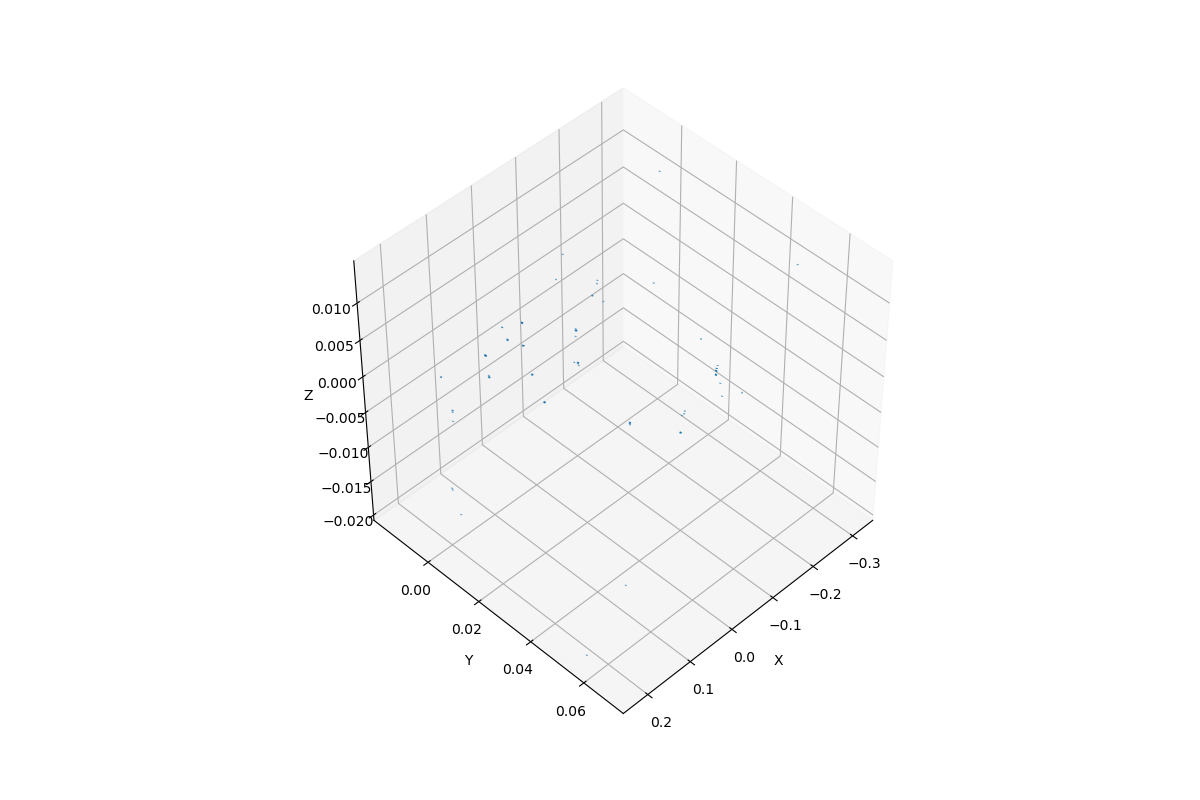

In [6]:
%matplotlib ipympl
poses1=poses[0:100]
origins = poses1[:, :3, -1]
dirs = np.stack([np.sum([1, 0, 0] * pose[:3, :3], axis=-1) for pose in poses1])
print(origins)

ax = plt.figure(figsize=(12, 8)).add_subplot(projection='3d')
_ = ax.quiver(
  origins[..., 0].flatten(),
  origins[..., 1].flatten(),
  origins[..., 2].flatten(),
  dirs[..., 0].flatten(),
  dirs[..., 1].flatten(),
  dirs[..., 2].flatten(), length=0.0005, normalize=True)
ax.set_box_aspect([1,1,1])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.view_init(45, 45) 
plt.show()